# Mental Health Clustering

**Proyecto Final — Aprendizaje No Supervisado**  

**Autores:** Ricardo Romero, Mauricio Gonzalez

**Repositorio:** `https://github.com/LogicRick/mental-health-clustering`

Este notebook está organizado para acompañar la estructura del repositorio de GitHub:

El objetivo es aplicar un flujo completo de aprendizaje no supervisado sobre un dataset público de salud mental y estilo de vida, incluyendo EDA, preprocesamiento, clustering, optimización, evaluación, visualización e interpretación crítica de resultados.

## 0. Introducción

La salud mental está relacionada con múltiples factores personales, sociales y de estilo de vida, como el sueño, el estrés laboral, el uso de redes sociales, la satisfacción laboral, el apoyo social y los hábitos cotidianos.

En este proyecto se analiza un dataset público relacionado con salud mental y estilo de vida con el propósito de identificar patrones naturales en los datos mediante técnicas de aprendizaje no supervisado.

A diferencia de un problema supervisado, aquí no se busca predecir una etiqueta principal, sino descubrir grupos de personas con características similares y analizar si esos grupos tienen sentido desde una perspectiva interpretativa.

## 1. Objetivos

### Objetivo general

Aplicar técnicas de aprendizaje no supervisado sobre un dataset público de salud mental y estilo de vida, realizando un proceso completo desde el análisis exploratorio hasta la interpretación crítica de los clusters obtenidos.

### Objetivos específicos

- Describir el dataset, sus variables y su origen público.
- Analizar la calidad de los datos, valores faltantes, distribuciones, correlaciones y posibles outliers.
- Preparar los datos mediante codificación, imputación, escalado y selección de variables.
- Implementar al menos dos algoritmos de clustering distintos, sin considerar K-Means como algoritmo principal.
- Optimizar hiperparámetros y justificar la elección final de los modelos.
- Evaluar los resultados mediante métricas internas y, si existen etiquetas disponibles, métricas externas.
- Visualizar los clusters mediante una técnica distinta de PCA, en este caso UMAP.
- Interpretar críticamente los resultados obtenidos.

## 2. Dataset

**Dataset utilizado:** Global Mental Health and Lifestyle Survey Dataset  
**Fuente pública:** Kaggle — `dhrubangtalukdar/global-mental-health-and-lifestyle-survey-dataset`  

El dataset contiene información demográfica, hábitos de vida, variables laborales y variables asociadas al bienestar mental.

## 3. Configuración del entorno

Esta sección importa las librerías necesarias, define la semilla de reproducibilidad y crea las carpetas donde se guardarán figuras y resultados.

In [2]:
# ============================================================
# 3. CONFIGURACIÓN DEL ENTORNO
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

import umap.umap_ as umap
import hdbscan

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo general de gráficos
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

# Se puede ejecutar desde la raíz del repo o desde notebooks/
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

# Subcarpetas de salida
for folder in [
    DATA_DIR,
    FIGURES_DIR,
    FIGURES_DIR / "eda",
    FIGURES_DIR / "clustering",
    FIGURES_DIR / "evaluation",
    RESULTS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_ROOT)
print("Carpeta de datos:", DATA_DIR)
print("Carpeta de figuras:", FIGURES_DIR)
print("Carpeta de resultados:", RESULTS_DIR)

Raíz del proyecto: /content
Carpeta de datos: /content/data
Carpeta de figuras: /content/figures
Carpeta de resultados: /content/results


## 4. Carga del dataset

Primero se intenta leer el archivo desde `data/mental_health.csv`. Si no existe localmente, se intenta descargar desde Kaggle usando `kagglehub`.

Esto permite que el notebook sea reproducible tanto en una computadora local como en un entorno nuevo, siempre que las dependencias estén instaladas y el acceso a Kaggle esté configurado.

In [3]:
# ============================================================
# 4. CARGA DEL DATASET
# ============================================================

DATASET_FILE = DATA_DIR / "mental_health.csv"

if DATASET_FILE.exists():
    print("Dataset encontrado localmente.")
    df = pd.read_csv(DATASET_FILE)
else:
    print("Dataset no encontrado en data/. Intentando descargar desde Kaggle...")
    try:
        import kagglehub
        kaggle_path = Path(kagglehub.dataset_download(
            "dhrubangtalukdar/global-mental-health-and-lifestyle-survey-dataset"
        ))
        downloaded_file = kaggle_path / "mental_health.csv"
        df = pd.read_csv(downloaded_file)
        df.to_csv(DATASET_FILE, index=False)
        print(f"Dataset descargado y guardado en: {DATASET_FILE}")
    except Exception as e:
        raise FileNotFoundError(
            "No se pudo cargar el dataset. Descargá manualmente mental_health.csv "
            "desde Kaggle y guardalo en la carpeta data/."
        ) from e

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")
display(df.head())

Dataset no encontrado en data/. Intentando descargar desde Kaggle...


100%|██████████| 402k/402k [00:00<00:00, 1.05MB/s]

Extracting files...


Dataset descargado y guardado en: /content/data/mental_health.csv
Dimensiones del dataset: 10000 filas y 51 columnas


,Age,Gender,Country,Education,Marital_Status,Income_Level,Employment_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,...,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Discuss_Mental_Health,Has_Mental_Health_Issue
0,40,Male,USA,Some College,Single,Middle,Full-time,27,No,6,...,1,0,0,0,9,3,4,6,Sometimes,1
1,33,Male,India,Bachelor,Married,Middle,Unemployed,47,No,6,...,0,0,0,0,3,2,7,7,Sometimes,1
2,42,Male,Other,High School,Single,Low,Full-time,53,No,1,...,1,0,0,1,5,3,6,9,Sometimes,1
3,53,Male,Germany,Bachelor,Single,Middle,Unemployed,42,No,10,...,0,1,0,0,1,3,10,5,Never,1
4,32,Female,India,Bachelor,Single,High,Student,13,No,4,...,0,0,0,0,1,5,1,6,Sometimes,1


## 5. Análisis Exploratorio de Datos (EDA)

El EDA permite conocer la estructura de los datos antes de aplicar clustering. En esta sección se revisan tipos de variables, valores faltantes, estadísticas descriptivas, distribuciones, correlaciones y posibles outliers.

In [4]:
# ============================================================
# 5.1 INFORMACIÓN GENERAL DEL DATASET
# ============================================================

print("Columnas del dataset:")
print(df.columns.tolist())

print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo"))

print("\nCantidad de valores faltantes por columna:")
missing_table = df.isna().sum().to_frame("faltantes")
missing_table["porcentaje"] = (missing_table["faltantes"] / len(df) * 100).round(2)
display(missing_table.sort_values("faltantes", ascending=False))

print("\nFilas duplicadas:", df.duplicated().sum())

Columnas del dataset:
['Age', 'Gender', 'Country', 'Education', 'Marital_Status', 'Income_Level', 'Employment_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Stress_Level', 'Work_Life_Balance', 'Ever_Bullied_At_Work', 'Company_Mental_Health_Support', 'Exercise_Per_Week', 'Sleep_Hours_Night', 'Caffeine_Drinks_Day', 'Alcohol_Frequency', 'Smoking', 'Screen_Time_Hours_Day', 'Social_Media_Hours_Day', 'Hobby_Time_Hours_Week', 'Diet_Quality', 'Financial_Stress', 'Feeling_Sad_Down', 'Loss_Of_Interest', 'Sleep_Trouble', 'Fatigue', 'Poor_Appetite_Or_Overeating', 'Feeling_Worthless', 'Concentration_Difficulty', 'Anxious_Nervous', 'Panic_Attacks', 'Mood_Swings', 'Irritability', 'Obsessive_Thoughts', 'Compulsive_Behavior', 'Self_Harm_Thoughts', 'Suicidal_Thoughts', 'Family_History_Mental_Illness', 'Previously_Diagnosed', 'Ever_Sought_Treatment', 'On_Therapy_Now', 'On_Medication', 'Trauma_History', 'Social_Support', 'Close_Friends_Count', 'Feel_Understood', 'Loneliness', 'Di

,tipo
Age,int64
Gender,object
Country,object
Education,object
Marital_Status,object
Income_Level,object
Employment_Status,object
Work_Hours_Per_Week,int64
Remote_Work,object
Job_Satisfaction,int64



Cantidad de valores faltantes por columna:


,faltantes,porcentaje
Age,0,0.0
Gender,0,0.0
Country,0,0.0
Education,0,0.0
Marital_Status,0,0.0
Income_Level,0,0.0
Employment_Status,0,0.0
Work_Hours_Per_Week,0,0.0
Remote_Work,0,0.0
Job_Satisfaction,0,0.0



Filas duplicadas: 0


In [5]:
# ============================================================
# 5.2 ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Variables numéricas ({len(numeric_cols)}):", numeric_cols)
print(f"Variables categóricas ({len(categorical_cols)}):", categorical_cols)

print("\nEstadísticas descriptivas de variables numéricas:")
display(df[numeric_cols].describe().T.round(2))

print("\nResumen de variables categóricas:")
display(df[categorical_cols].describe().T if categorical_cols else "No hay variables categóricas.")

Variables numéricas (38): ['Age', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Stress_Level', 'Work_Life_Balance', 'Ever_Bullied_At_Work', 'Sleep_Hours_Night', 'Caffeine_Drinks_Day', 'Screen_Time_Hours_Day', 'Social_Media_Hours_Day', 'Hobby_Time_Hours_Week', 'Financial_Stress', 'Feeling_Sad_Down', 'Loss_Of_Interest', 'Sleep_Trouble', 'Fatigue', 'Poor_Appetite_Or_Overeating', 'Feeling_Worthless', 'Concentration_Difficulty', 'Anxious_Nervous', 'Panic_Attacks', 'Mood_Swings', 'Irritability', 'Obsessive_Thoughts', 'Compulsive_Behavior', 'Self_Harm_Thoughts', 'Suicidal_Thoughts', 'Family_History_Mental_Illness', 'Previously_Diagnosed', 'Ever_Sought_Treatment', 'On_Therapy_Now', 'On_Medication', 'Trauma_History', 'Social_Support', 'Close_Friends_Count', 'Feel_Understood', 'Loneliness', 'Has_Mental_Health_Issue']
Variables categóricas (13): ['Gender', 'Country', 'Education', 'Marital_Status', 'Income_Level', 'Employment_Status', 'Remote_Work', 'Company_Mental_Health_Support', 'Exercise_Pe

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,34.95,11.16,18.0,26.0,34.0,43.0,75.0
Work_Hours_Per_Week,10000.0,39.66,10.02,0.0,33.0,40.0,46.0,74.0
Job_Satisfaction,10000.0,5.50,2.88,1.0,3.0,6.0,8.0,10.0
Work_Stress_Level,10000.0,5.49,2.88,1.0,3.0,6.0,8.0,10.0
Work_Life_Balance,10000.0,5.49,2.88,1.0,3.0,5.0,8.0,10.0
Ever_Bullied_At_Work,10000.0,0.25,0.43,0.0,0.0,0.0,0.0,1.0
Sleep_Hours_Night,10000.0,6.82,1.38,3.0,5.9,6.8,7.7,11.0
Caffeine_Drinks_Day,10000.0,2.02,1.43,0.0,1.0,2.0,3.0,8.0
Screen_Time_Hours_Day,10000.0,7.06,2.96,1.0,5.0,7.0,9.1,16.0
Social_Media_Hours_Day,10000.0,3.14,2.25,0.0,1.3,3.0,4.7,12.0



Resumen de variables categóricas:


,count,unique,top,freq
Gender,10000,4,Female,4892
Country,10000,6,USA,2519
Education,10000,5,Bachelor,3493
Marital_Status,10000,4,Single,4523
Income_Level,10000,3,Middle,5059
Employment_Status,10000,5,Full-time,4473
Remote_Work,10000,3,No,4958
Company_Mental_Health_Support,10000,3,No,5526
Exercise_Per_Week,10000,4,1-2 times,3493
Alcohol_Frequency,10000,4,Rarely,3984


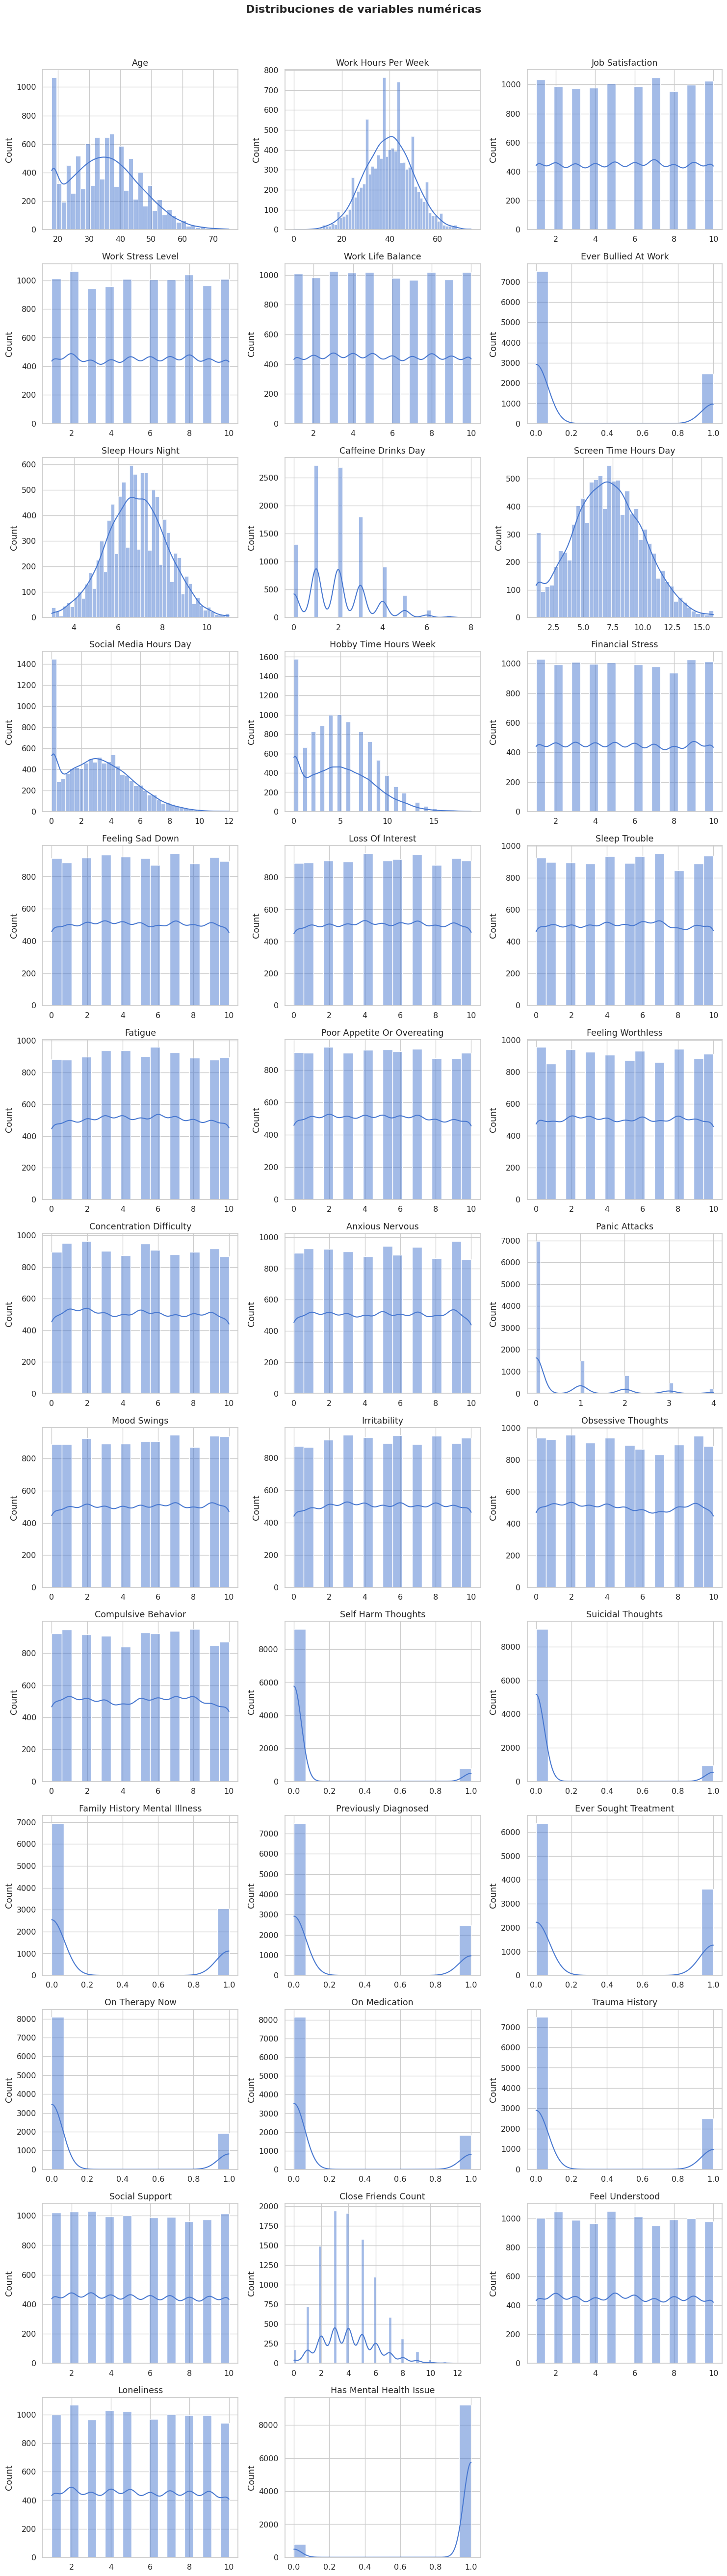

In [6]:
# ============================================================
# 5.3 DISTRIBUCIONES DE VARIABLES NUMÉRICAS
# ============================================================

# Se grafican todas las variables numéricas disponibles.
cols_to_plot = numeric_cols

n_cols = 3
n_rows = int(np.ceil(len(cols_to_plot) / n_cols)) if cols_to_plot else 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cols_to_plot):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("")

for ax in axes[len(cols_to_plot):]:
    ax.axis("off")

plt.suptitle("Distribuciones de variables numéricas", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda" / "distribuciones_numericas.png", dpi=300, bbox_inches="tight")
plt.show()

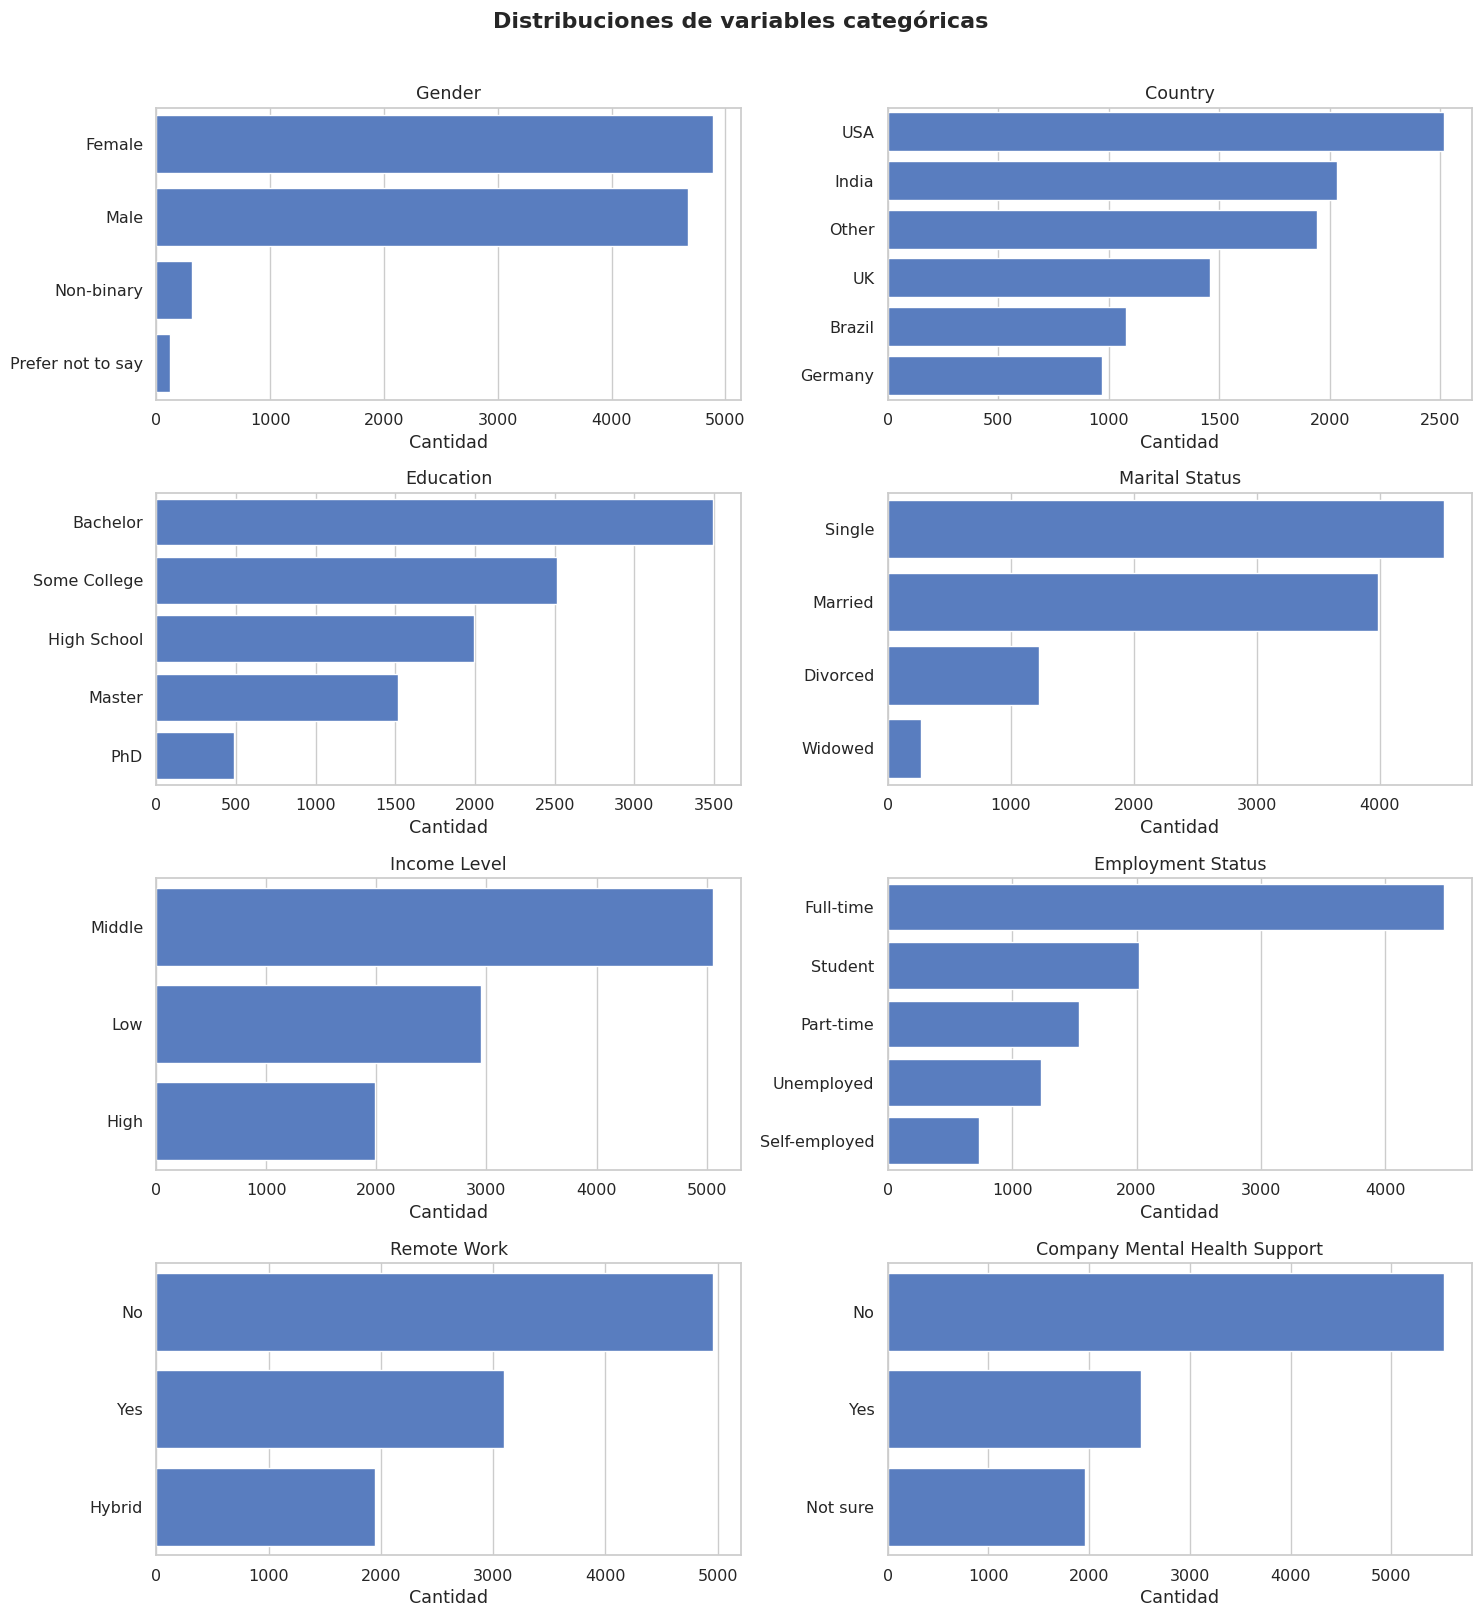

In [7]:
# ============================================================
# 5.4 DISTRIBUCIONES DE VARIABLES CATEGÓRICAS
# ============================================================

# Para evitar gráficos demasiado grandes, se muestran como máximo 8 variables categóricas.
cat_to_plot = categorical_cols[:8]

if cat_to_plot:
    n_cols = 2
    n_rows = int(np.ceil(len(cat_to_plot) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cat_to_plot):
        order = df[col].value_counts().index
        sns.countplot(data=df, y=col, order=order, ax=ax)
        ax.set_title(col.replace("_", " "))
        ax.set_xlabel("Cantidad")
        ax.set_ylabel("")

    for ax in axes[len(cat_to_plot):]:
        ax.axis("off")

    plt.suptitle("Distribuciones de variables categóricas", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda" / "distribuciones_categoricas.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No hay variables categóricas para graficar.")

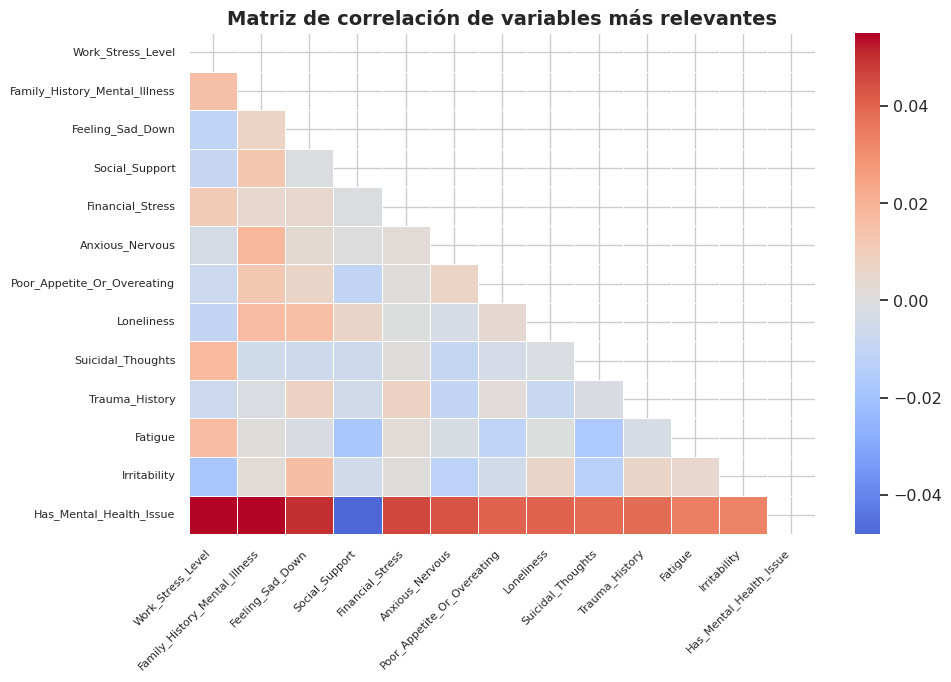

Principales correlaciones absolutas:


,variable_1,variable_2,correlacion
669,Has_Mental_Health_Issue,Work_Stress_Level,0.055
693,Has_Mental_Health_Issue,Family_History_Mental_Illness,0.055
678,Has_Mental_Health_Issue,Feeling_Sad_Down,0.050
699,Has_Mental_Health_Issue,Social_Support,-0.048
677,Has_Mental_Health_Issue,Financial_Stress,0.046
685,Has_Mental_Health_Issue,Anxious_Nervous,0.044
682,Has_Mental_Health_Issue,Poor_Appetite_Or_Overeating,0.041
702,Has_Mental_Health_Issue,Loneliness,0.040
692,Has_Mental_Health_Issue,Suicidal_Thoughts,0.039
698,Has_Mental_Health_Issue,Trauma_History,0.038


In [8]:
# ============================================================
# 5.5 MATRIZ DE CORRELACIÓN
# ============================================================

if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()

    # Nos quedamos solo con las correlaciones más relevantes
    corr_target = corr["Has_Mental_Health_Issue"].drop("Has_Mental_Health_Issue").abs()
    top_vars = corr_target.sort_values(ascending=False).head(12).index.tolist()

    corr_top = df[top_vars + ["Has_Mental_Health_Issue"]].corr()
    mask = np.triu(np.ones_like(corr_top, dtype=bool))

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        corr_top,
        mask=mask,
        annot=False,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot_kws={"size": 8}
    )

    plt.title(
        "Matriz de correlación de variables más relevantes",
        fontsize=14,
        fontweight="bold"
    )
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / "eda" / "correlaciones_top.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    corr_pairs = (
        corr.where(~np.triu(np.ones_like(corr, dtype=bool)))
        .stack()
        .reset_index()
        .rename(columns={
            "level_0": "variable_1",
            "level_1": "variable_2",
            0: "correlacion"
        })
        .assign(abs_corr=lambda x: x["correlacion"].abs())
        .sort_values("abs_corr", ascending=False)
        .drop(columns="abs_corr")
    )

    print("Principales correlaciones absolutas:")
    display(corr_pairs.head(10).round(3))

else:
    print("No hay suficientes variables numéricas para calcular correlaciones.")

,variable,outliers_iqr,porcentaje,limite_inferior,limite_superior
28,Previously_Diagnosed,2480,24.80,0.00,0.00
5,Ever_Bullied_At_Work,2474,24.74,0.00,0.00
30,On_Therapy_Now,1910,19.10,0.00,0.00
31,On_Medication,1843,18.43,0.00,0.00
26,Suicidal_Thoughts,952,9.52,0.00,0.00
37,Has_Mental_Health_Issue,784,7.84,1.00,1.00
25,Self_Harm_Thoughts,781,7.81,0.00,0.00
20,Panic_Attacks,697,6.97,-1.50,2.50
34,Close_Friends_Count,217,2.17,0.00,8.00
1,Work_Hours_Per_Week,94,0.94,13.50,65.50


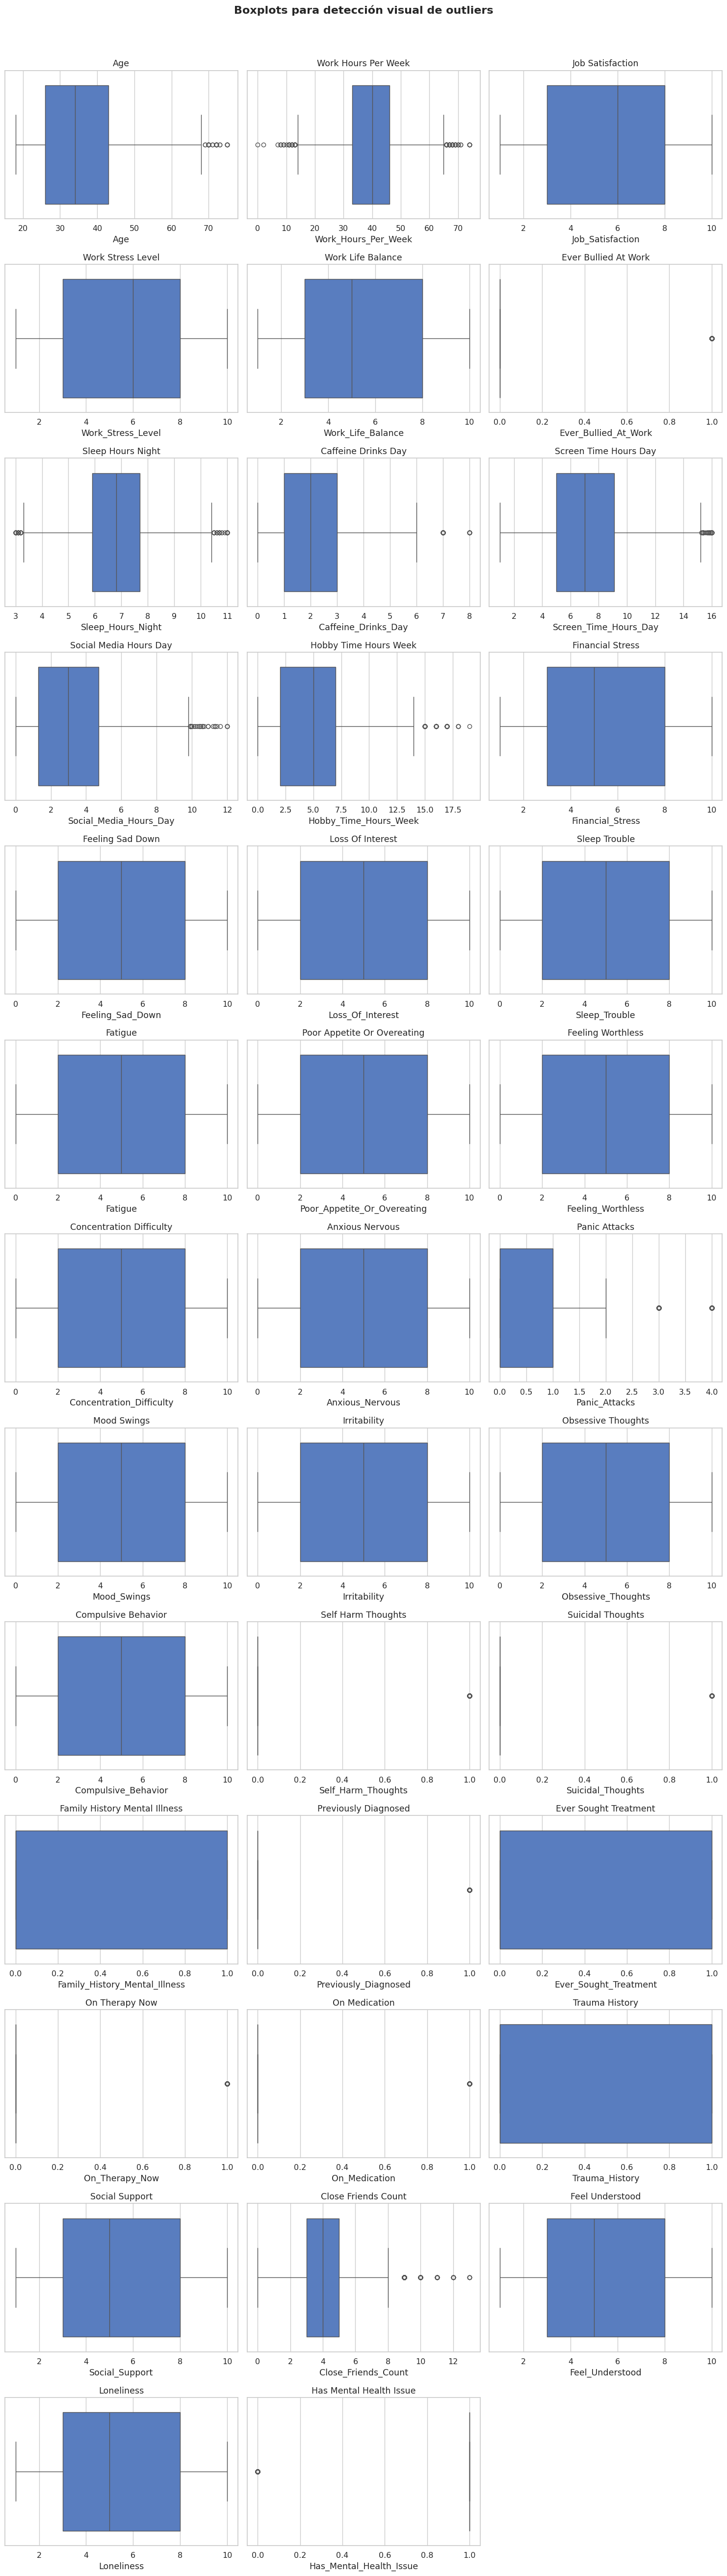

In [9]:
# ============================================================
# 5.6 DETECCIÓN EXPLORATORIA DE OUTLIERS
# ============================================================

# Método IQR: identifica valores extremos por variable numérica.
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "variable": col,
        "outliers_iqr": int(n_out),
        "porcentaje": round(n_out / len(df) * 100, 2),
        "limite_inferior": round(lower, 2),
        "limite_superior": round(upper, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("outliers_iqr", ascending=False)
display(outlier_summary)

# Boxplots de variables numéricas
if numeric_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, numeric_cols):
        sns.boxplot(x=df[col], ax=ax)
        ax.set_title(col.replace("_", " "))

    for ax in axes[len(numeric_cols):]:
        ax.axis("off")

    plt.suptitle("Boxplots para detección visual de outliers", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda" / "boxplots_outliers.png", dpi=300, bbox_inches="tight")
    plt.show()

### 5.7 Conclusiones preliminares del EDA

A partir del EDA se deben revisar los siguientes puntos antes del clustering:

- Si existen valores faltantes y cómo serán tratados.
- Si las variables están en escalas diferentes, lo cual justifica aplicar estandarización.
- Si existen variables categóricas, deben codificarse antes de entrenar modelos.
- Si existen outliers, deben interpretarse con cuidado, ya que en salud mental pueden representar perfiles relevantes y no necesariamente errores.
- Las correlaciones permiten identificar relaciones entre variables y ayudan a interpretar los clusters posteriormente.

## 6. Preprocesamiento

El clustering es sensible a la escala de las variables. Por este motivo se realiza:

1. **Imputación simple:** se completan valores faltantes con la mediana para variables numéricas y con la moda para variables categóricas.
2. **Codificación:** las variables categóricas se transforman mediante one-hot encoding.
3. **Escalado:** se usa `StandardScaler` para que todas las variables tengan media 0 y desviación estándar 1.
4. **Separación de etiqueta externa:** si existe una variable como `Has_Mental_Health_Issue`, se reserva para evaluación externa y no se usa como variable de entrada al clustering.

In [12]:
# ============================================================
# 6. PREPROCESAMIENTO
# ============================================================

df_model = df.copy()

# Esta columna NO se usará como entrada de clustering.
target_candidates = ["Has_Mental_Health_Issue", "Mental_Health_Issue", "Diagnosis"]
target_col = next((c for c in target_candidates if c in df_model.columns), None)

if target_col:
    y_external_raw = df_model[target_col].copy()
    df_features = df_model.drop(columns=[target_col])
    print(f"Etiqueta externa detectada para evaluación: {target_col}")
else:
    y_external_raw = None
    df_features = df_model.copy()
    print("No se detectó una etiqueta externa para evaluación.")

# Imputación básica
for col in df_features.columns:
    if pd.api.types.is_numeric_dtype(df_features[col]):
        df_features[col] = df_features[col].fillna(df_features[col].median())
    else:
        mode_value = df_features[col].mode(dropna=True)
        fill_value = mode_value.iloc[0] if len(mode_value) > 0 else "Desconocido"
        df_features[col] = df_features[col].fillna(fill_value)

# Codificación de variables categóricas
df_encoded = pd.get_dummies(df_features, drop_first=False)

# Conversión explícita a float para evitar problemas con modelos de sklearn
X_raw = df_encoded.astype(float).values
feature_names = df_encoded.columns.tolist()

# Escalado
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Matriz final para clustering:", X.shape)
print("Cantidad de variables después de codificación:", len(feature_names))

# ============================================================
# 6.1 PREPARACIÓN DE ETIQUETA EXTERNA
# ============================================================

if y_external_raw is not None:
    le = LabelEncoder()
    y_external = le.fit_transform(y_external_raw.astype(str))
    print("Clases externas detectadas:")
    for idx, name in enumerate(le.classes_):
        print(f"{idx}: {name}")
else:
    y_external = None

Etiqueta externa detectada para evaluación: Has_Mental_Health_Issue
Matriz final para clustering: (10000, 89)
Cantidad de variables después de codificación: 89
Clases externas detectadas:
0: 0
1: 1


## 7. Visualización no lineal con UMAP

Se emplea **UMAP**, que permite proyectar datos de alta dimensión a dos dimensiones intentando conservar relaciones locales entre observaciones.

Ojo que UMAP se utiliza principalmente para visualización e interpretación, no como única evidencia para decidir la calidad de un clustering.

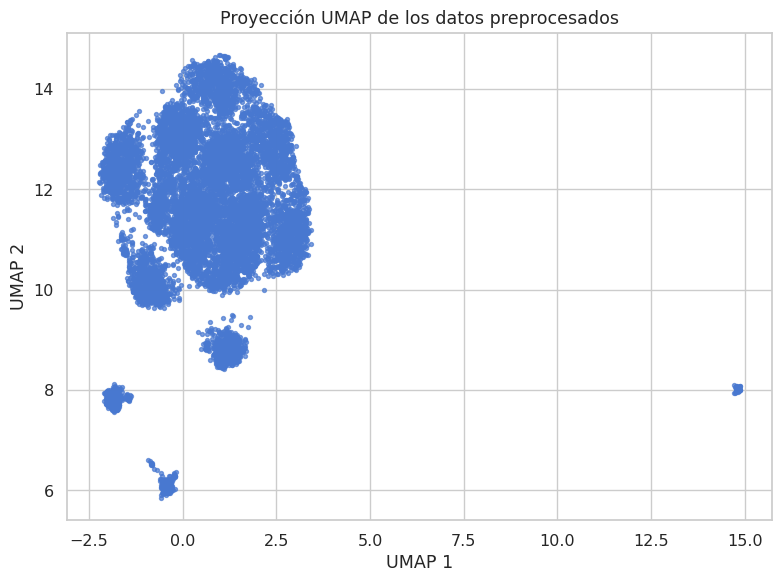

In [13]:
# ============================================================
# 7. UMAP PARA VISUALIZACIÓN
# ============================================================

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.10,
    metric="euclidean",
    random_state=SEED,
)

X_umap = umap_model.fit_transform(X)

umap_df = pd.DataFrame(X_umap, columns=["UMAP_1", "UMAP_2"])

plt.figure(figsize=(8, 6))
plt.scatter(umap_df["UMAP_1"], umap_df["UMAP_2"], s=8, alpha=0.7)
plt.title("Proyección UMAP de los datos preprocesados")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "clustering" / "umap_base.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Funciones auxiliares para evaluación

Se definen funciones para calcular métricas internas y externas de manera uniforme.

Métricas internas utilizadas:

- **Silhouette Score:** valores mayores indican clusters más compactos y separados.
- **Davies-Bouldin Index:** valores menores indican mejor separación relativa.
- **Calinski-Harabasz Index:** valores mayores suelen indicar mejor estructura de clusters.

Métricas externas:

- **Adjusted Rand Index (ARI).**
- **Normalized Mutual Information (NMI).**

In [15]:
# ============================================================
# 8. FUNCIONES AUXILIARES
# ============================================================

def n_clusters_validos(labels):
    """Cuenta clusters válidos, ignorando ruido identificado como -1."""
    unique = set(labels)
    return len(unique) - (1 if -1 in unique else 0)


def evaluar_clustering(nombre, labels, X_eval, y_external=None, nota=""):
    """Calcula métricas internas y externas para un clustering."""
    labels = np.asarray(labels)
    mask = labels != -1
    n_clusters = n_clusters_validos(labels)
    noise_ratio = float((labels == -1).mean()) if -1 in labels else 0.0

    result = {
        "modelo": nombre,
        "clusters": n_clusters,
        "ruido_%": round(noise_ratio * 100, 2),
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
        "ari": np.nan,
        "nmi": np.nan,
        "nota": nota,
    }

    # Las métricas internas requieren al menos 2 clusters y más puntos que clusters
    if n_clusters >= 2 and mask.sum() > n_clusters:
        X_clean = X_eval[mask]
        labels_clean = labels[mask]
        result["silhouette"] = round(silhouette_score(X_clean, labels_clean), 4)
        result["davies_bouldin"] = round(davies_bouldin_score(X_clean, labels_clean), 4)
        result["calinski_harabasz"] = round(calinski_harabasz_score(X_clean, labels_clean), 4)

    # Métricas externas, solo si hay etiqueta externa
    if y_external is not None and n_clusters >= 2:
        result["ari"] = round(adjusted_rand_score(y_external[mask], labels[mask]), 4)
        result["nmi"] = round(normalized_mutual_info_score(y_external[mask], labels[mask]), 4)

    return result


def plot_clusters_umap(labels, title, filename):
    """Grafica clusters sobre UMAP y guarda la figura."""
    labels = np.asarray(labels)
    plt.figure(figsize=(8, 6))
    unique_labels = sorted(set(labels))

    for lbl in unique_labels:
        mask = labels == lbl
        label_name = "Ruido" if lbl == -1 else f"Cluster {lbl}"
        plt.scatter(X_umap[mask, 0], X_umap[mask, 1], s=8, alpha=0.7, label=label_name)

    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(markerscale=2, fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "clustering" / filename, dpi=300, bbox_inches="tight")
    plt.show()


def perfil_clusters(df_original, labels, variables=None):
    """Calcula perfiles promedio de clusters usando variables numéricas interpretables."""
    labels = np.asarray(labels)
    df_tmp = df_original.copy()
    df_tmp["cluster"] = labels

    if variables is None:
        variables = df_tmp.select_dtypes(include=[np.number]).columns.tolist()
        variables = [v for v in variables if v != "cluster"]

    return df_tmp[df_tmp["cluster"] != -1].groupby("cluster")[variables].mean().round(2)

## 9. Algoritmo de referencia: K-Means

K-Means se utiliza únicamente como línea base de comparación.

,modelo,clusters,ruido_%,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,nota,k
0,K-Means k=2,2,0.0,0.0213,6.7535,217.2243,0.0006,0.0005,Baseline,2
1,K-Means k=3,3,0.0,0.0272,5.7801,175.5313,-0.0067,0.0004,Baseline,3
2,K-Means k=4,4,0.0,0.0209,5.9632,162.5969,-0.0011,0.0004,Baseline,4
3,K-Means k=5,5,0.0,0.0209,5.6384,145.2791,-0.0000,0.0003,Baseline,5
4,K-Means k=6,6,0.0,0.0221,5.4121,134.1487,-0.0004,0.0003,Baseline,6
5,K-Means k=7,7,0.0,0.0198,5.1361,126.4831,-0.0003,0.0004,Baseline,7
6,K-Means k=8,8,0.0,0.0230,5.0606,121.0016,-0.0005,0.0002,Baseline,8
7,K-Means k=9,9,0.0,0.0214,5.0083,113.1985,-0.0008,0.0004,Baseline,9


Mejor K-Means de referencia: k=3


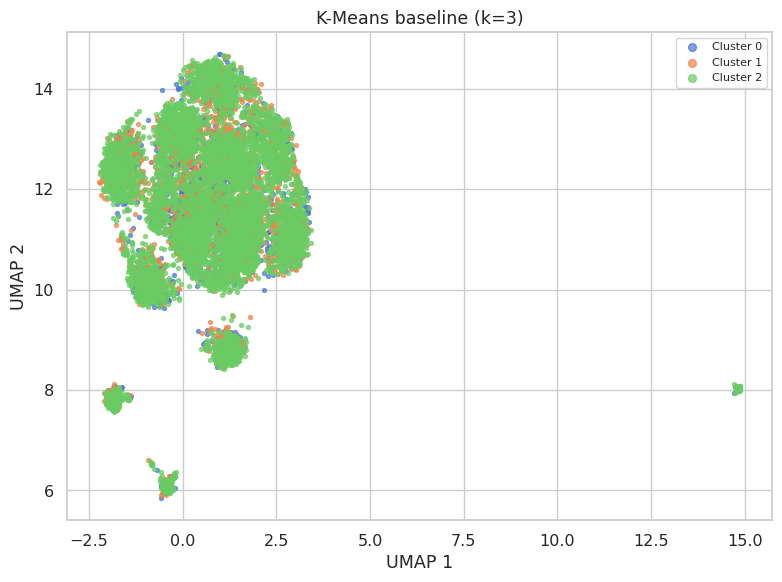

In [16]:
# ============================================================
# 9. K-MEANS - BASELINE
# ============================================================

kmeans_results = []
for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = model.fit_predict(X)
    metrics = evaluar_clustering(f"K-Means k={k}", labels, X, y_external, nota="Baseline")
    metrics["k"] = k
    kmeans_results.append(metrics)

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df)

# Selección simple: mayor silhouette.
best_kmeans_row = kmeans_results_df.sort_values("silhouette", ascending=False).iloc[0]
best_kmeans_k = int(best_kmeans_row["k"])

kmeans_final = KMeans(n_clusters=best_kmeans_k, random_state=SEED, n_init=20)
labels_kmeans = kmeans_final.fit_predict(X)

print(f"Mejor K-Means de referencia: k={best_kmeans_k}")
plot_clusters_umap(labels_kmeans, f"K-Means baseline (k={best_kmeans_k})", "kmeans_baseline_umap.png")

## 10. Algoritmo 1: HDBSCAN

HDBSCAN es un algoritmo basado en densidad. A diferencia de K-Means, no requiere fijar previamente el número de clusters y puede identificar puntos de ruido.

Se realiza una búsqueda de hiperparámetros sobre:

- `min_cluster_size`
- `min_samples`

La elección final se basa en las métricas internas y en que el modelo produzca una estructura interpretable, evitando soluciones triviales con demasiados puntos marcados como ruido.

,modelo,clusters,ruido_%,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,nota,min_cluster_size,min_samples
0,"HDBSCAN mcs=15, ms=5",2,0.21,0.1832,1.9522,106.3719,-0.0005,0.0,Clustering por densidad,15,5
6,"HDBSCAN mcs=50, ms=5",2,0.21,0.1832,1.9522,106.3719,-0.0005,0.0,Clustering por densidad,50,5
3,"HDBSCAN mcs=30, ms=5",2,0.21,0.1832,1.9522,106.3719,-0.0005,0.0,Clustering por densidad,30,5
9,"HDBSCAN mcs=75, ms=5",2,0.21,0.1832,1.9522,106.3719,-0.0005,0.0,Clustering por densidad,75,5
1,"HDBSCAN mcs=15, ms=10",2,0.53,0.1784,1.9268,85.7514,-0.0013,0.0,Clustering por densidad,15,10
10,"HDBSCAN mcs=75, ms=10",2,0.53,0.1784,1.9268,85.7514,-0.0013,0.0,Clustering por densidad,75,10
4,"HDBSCAN mcs=30, ms=10",2,0.53,0.1784,1.9268,85.7514,-0.0013,0.0,Clustering por densidad,30,10
7,"HDBSCAN mcs=50, ms=10",2,0.53,0.1784,1.9268,85.7514,-0.0013,0.0,Clustering por densidad,50,10
2,"HDBSCAN mcs=15, ms=20",2,0.87,0.1729,1.8956,62.8955,0.0005,0.0,Clustering por densidad,15,20
5,"HDBSCAN mcs=30, ms=20",2,0.87,0.1729,1.8956,62.8955,0.0005,0.0,Clustering por densidad,30,20


Mejores hiperparámetros HDBSCAN:


,modelo,clusters,ruido_%,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,nota,min_cluster_size,min_samples
0,"HDBSCAN mcs=15, ms=5",2,0.21,0.1832,1.9522,106.3719,-0.0005,0.0,Clustering por densidad,15,5


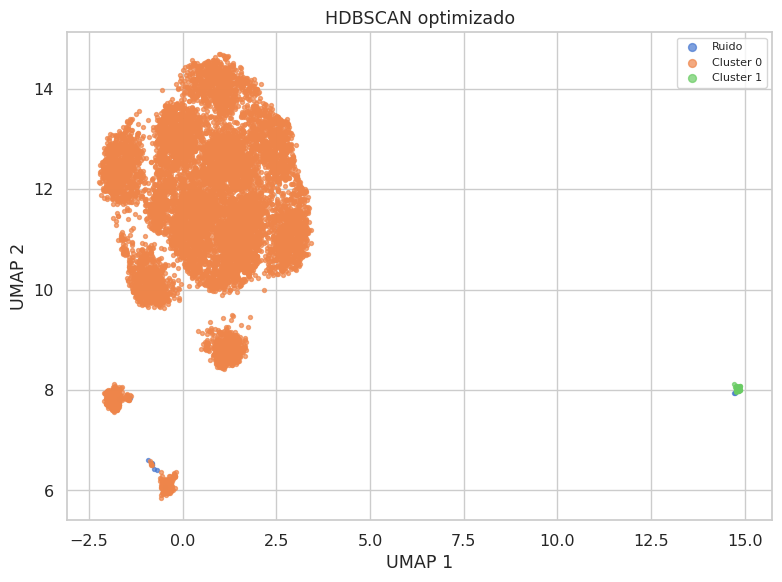

In [17]:
# ============================================================
# 10. OPTIMIZACIÓN DE HDBSCAN
# ============================================================

hdbscan_grid = []

for min_cluster_size in [15, 30, 50, 75]:
    for min_samples in [5, 10, 20]:
        model = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
        )
        # Se usa X para entrenar, y las métricas también se calculan sobre X.
        labels = model.fit_predict(X)
        metrics = evaluar_clustering(
            f"HDBSCAN mcs={min_cluster_size}, ms={min_samples}",
            labels,
            X,
            y_external,
            nota="Clustering por densidad",
        )
        metrics["min_cluster_size"] = min_cluster_size
        metrics["min_samples"] = min_samples
        hdbscan_grid.append(metrics)

hdbscan_results_df = pd.DataFrame(hdbscan_grid)
display(hdbscan_results_df.sort_values("silhouette", ascending=False))

# Criterio práctico: maximizar silhouette entre soluciones con al menos 2 clusters.
hdb_valid = hdbscan_results_df[hdbscan_results_df["clusters"] >= 2].copy()
best_hdb_row = hdb_valid.sort_values("silhouette", ascending=False).iloc[0]

best_hdbscan = hdbscan.HDBSCAN(
    min_cluster_size=int(best_hdb_row["min_cluster_size"]),
    min_samples=int(best_hdb_row["min_samples"]),
    metric="euclidean",
)
labels_hdbscan = best_hdbscan.fit_predict(X)

print("Mejores hiperparámetros HDBSCAN:")
display(best_hdb_row.to_frame().T)
plot_clusters_umap(labels_hdbscan, "HDBSCAN optimizado", "hdbscan_umap.png")

## 11. Algoritmo 2: Gaussian Mixture Model (GMM)

GMM modela los datos como una mezcla de distribuciones gaussianas. A diferencia de K-Means, permite una interpretación probabilística, ya que cada observación tiene una probabilidad de pertenecer a cada componente.

Se optimiza el número de componentes utilizando BIC y AIC. En general, un menor BIC indica un mejor equilibrio entre ajuste y complejidad del modelo.

,modelo,clusters,ruido_%,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,nota,k,bic,aic
7,GMM k=9,9,0.0,0.0214,5.0083,113.1989,-0.0008,0.0004,Modelo probabilístico,9,14464.74,-251265.14
6,GMM k=8,8,0.0,0.0191,5.3380,115.5229,-0.0009,0.0002,Modelo probabilístico,8,92960.71,-143242.84
5,GMM k=7,7,0.0,0.0209,5.4669,116.1399,-0.0005,0.0002,Modelo probabilístico,7,108196.39,-98480.81
4,GMM k=6,6,0.0,0.0209,5.7161,125.9696,0.0010,0.0003,Modelo probabilístico,6,193966.70,16815.85
3,GMM k=5,5,0.0,0.0206,5.9431,114.0803,-0.0076,0.0009,Modelo probabilístico,5,207327.32,59702.81
2,GMM k=4,4,0.0,0.0184,6.0704,144.9287,-0.0005,0.0002,Modelo probabilístico,4,290669.72,172571.56
1,GMM k=3,3,0.0,0.0138,6.4784,167.9176,0.0019,0.0005,Modelo probabilístico,3,419957.64,331385.82
0,GMM k=2,2,0.0,0.1222,3.7067,118.6324,-0.0043,0.0001,Modelo probabilístico,2,494040.98,434995.50


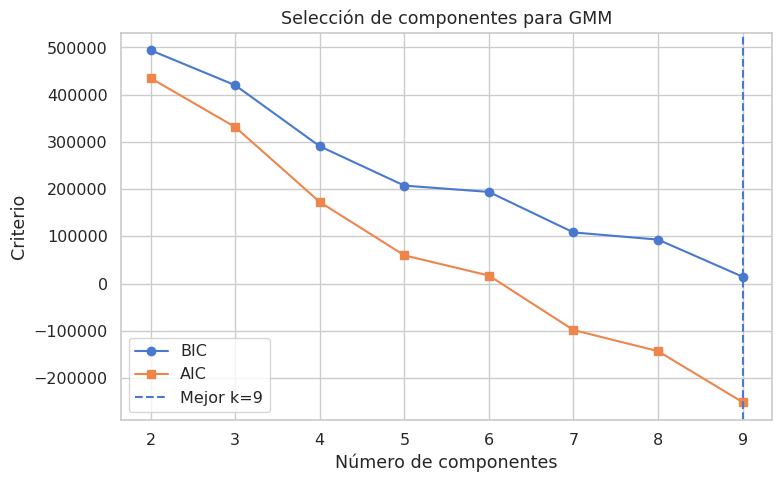

Mejor GMM según BIC: k=9


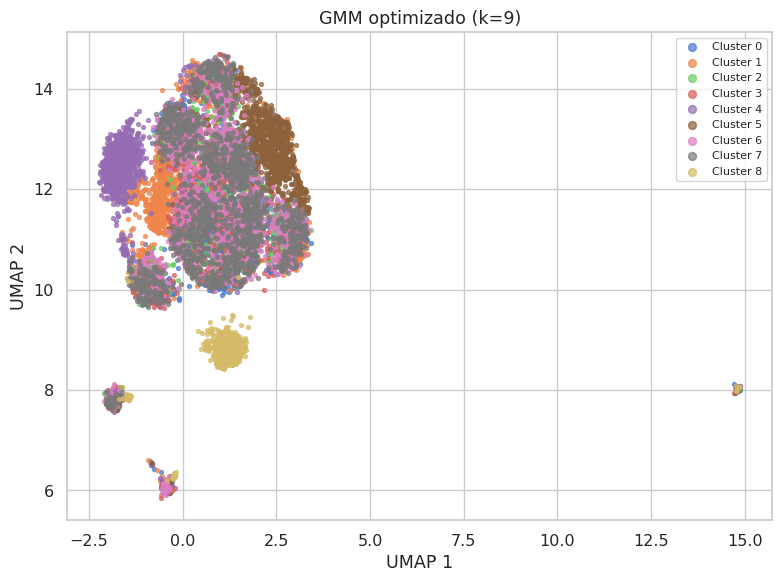

In [18]:
# ============================================================
# 11. OPTIMIZACIÓN DE GMM
# ============================================================

gmm_grid = []

for k in range(2, 10):
    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=SEED,
        n_init=5,
    )
    model.fit(X)
    labels = model.predict(X)
    metrics = evaluar_clustering(f"GMM k={k}", labels, X, y_external, nota="Modelo probabilístico")
    metrics["k"] = k
    metrics["bic"] = round(model.bic(X), 2)
    metrics["aic"] = round(model.aic(X), 2)
    gmm_grid.append(metrics)

gmm_results_df = pd.DataFrame(gmm_grid)
display(gmm_results_df.sort_values("bic"))

best_gmm_row = gmm_results_df.sort_values("bic", ascending=True).iloc[0]
best_gmm_k = int(best_gmm_row["k"])

# Gráfico BIC/AIC
plt.figure(figsize=(8, 5))
plt.plot(gmm_results_df["k"], gmm_results_df["bic"], marker="o", label="BIC")
plt.plot(gmm_results_df["k"], gmm_results_df["aic"], marker="s", label="AIC")
plt.axvline(best_gmm_k, linestyle="--", label=f"Mejor k={best_gmm_k}")
plt.xlabel("Número de componentes")
plt.ylabel("Criterio")
plt.title("Selección de componentes para GMM")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "evaluation" / "gmm_bic_aic.png", dpi=300, bbox_inches="tight")
plt.show()

# Modelo final
best_gmm = GaussianMixture(
    n_components=best_gmm_k,
    covariance_type="full",
    random_state=SEED,
    n_init=10,
)
best_gmm.fit(X)
labels_gmm = best_gmm.predict(X)
proba_gmm = best_gmm.predict_proba(X)

print(f"Mejor GMM según BIC: k={best_gmm_k}")
plot_clusters_umap(labels_gmm, f"GMM optimizado (k={best_gmm_k})", "gmm_umap.png")

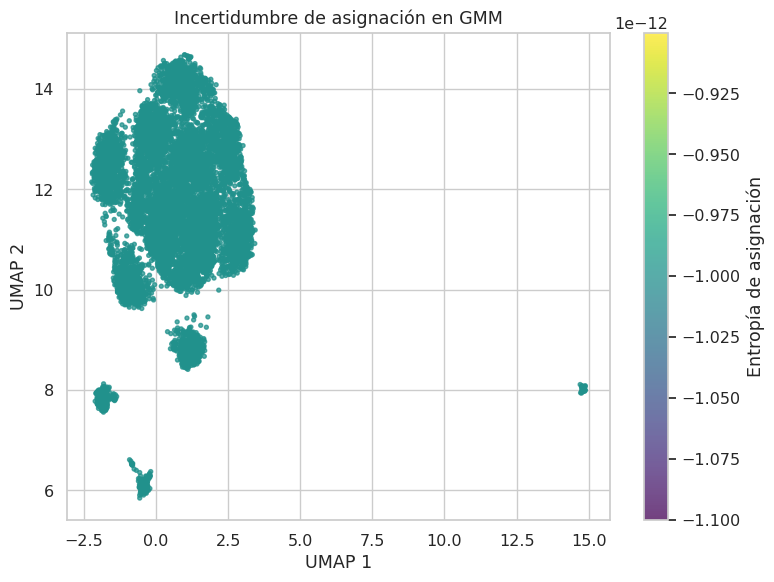

In [19]:
# ============================================================
# 11.1 INCERTIDUMBRE DE ASIGNACIÓN EN GMM
# ============================================================

# La entropía mide cuán incierta es la asignación de cada punto.
entropy = -(proba_gmm * np.log(proba_gmm + 1e-12)).sum(axis=1)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=entropy, s=8, alpha=0.75, cmap="viridis")
plt.colorbar(sc, label="Entropía de asignación")
plt.title("Incertidumbre de asignación en GMM")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "clustering" / "gmm_incertidumbre_umap.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Algoritmo 3: Spectral Clustering con aumento de dimensionalidad

Spectral Clustering construye una representación basada en grafos de vecindad, lo que puede capturar estructuras no lineales.

Para enriquecer la representación, se utiliza un pipeline:

```text
Datos escalados → PCA → expansión polinómica → escalado → Spectral Clustering
```

PCA aquí no se usa como visualización final, sino como reducción intermedia para hacer manejable la expansión polinómica.

Dimensión original: 89
Dimensión luego de PCA 90%: 67
Dimensión luego de expansión polinómica: 2345


,modelo,clusters,ruido_%,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,nota,k,n_neighbors
0,"Spectral k=2, nn=10",2,0.0,0.1738,1.9602,50.4377,0.0044,0.0003,Grafo de vecinos + expansión polinómica,2,10
1,"Spectral k=2, nn=15",2,0.0,0.0048,14.4427,45.4808,0.0027,0.0002,Grafo de vecinos + expansión polinómica,2,15
2,"Spectral k=2, nn=20",2,0.0,0.0047,14.5998,45.4357,0.0011,0.0001,Grafo de vecinos + expansión polinómica,2,20
5,"Spectral k=3, nn=20",3,0.0,0.0045,11.7888,49.5176,0.0022,0.0002,Grafo de vecinos + expansión polinómica,3,20
4,"Spectral k=3, nn=15",3,0.0,0.0039,12.6140,45.4572,0.0017,0.0001,Grafo de vecinos + expansión polinómica,3,15
7,"Spectral k=4, nn=15",4,0.0,0.0036,11.2196,44.6010,-0.0009,0.0004,Grafo de vecinos + expansión polinómica,4,15
8,"Spectral k=4, nn=20",4,0.0,0.0036,10.6908,51.3376,0.0018,0.0008,Grafo de vecinos + expansión polinómica,4,20
3,"Spectral k=3, nn=10",3,0.0,0.0034,11.7562,43.0834,0.0011,0.0003,Grafo de vecinos + expansión polinómica,3,10
11,"Spectral k=5, nn=20",5,0.0,0.0023,10.5057,45.1128,0.0008,0.0005,Grafo de vecinos + expansión polinómica,5,20
14,"Spectral k=6, nn=20",6,0.0,-0.0001,10.3079,43.2397,0.0014,0.0006,Grafo de vecinos + expansión polinómica,6,20


Mejores hiperparámetros Spectral Clustering:


,modelo,clusters,ruido_%,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,nota,k,n_neighbors
0,"Spectral k=2, nn=10",2,0.0,0.1738,1.9602,50.4377,0.0044,0.0003,Grafo de vecinos + expansión polinómica,2,10


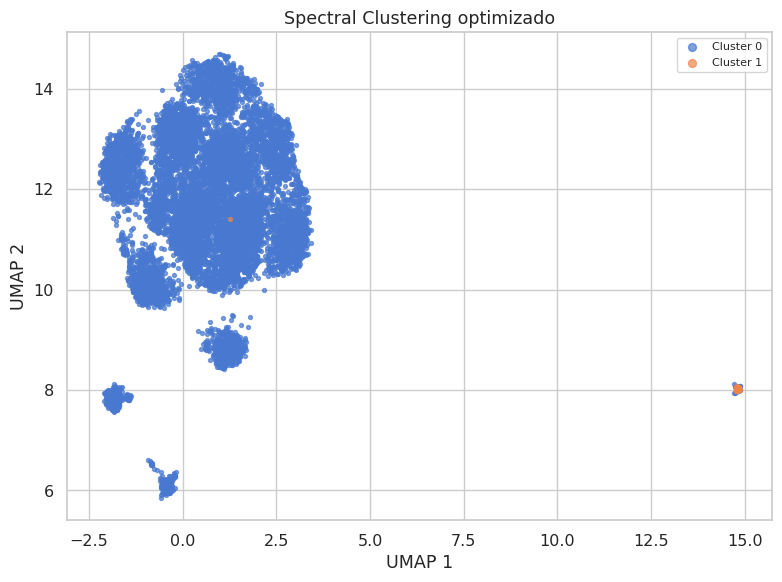

In [20]:
# ============================================================
# 12. SPECTRAL CLUSTERING CON AUMENTO DE DIMENSIONALIDAD
# ============================================================

# Reducción intermedia para evitar una expansión polinómica demasiado grande.
pca = PCA(n_components=0.90, random_state=SEED)
X_pca = pca.fit_transform(X)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_pca)
X_poly = StandardScaler().fit_transform(X_poly)

print(f"Dimensión original: {X.shape[1]}")
print(f"Dimensión luego de PCA 90%: {X_pca.shape[1]}")
print(f"Dimensión luego de expansión polinómica: {X_poly.shape[1]}")

spectral_grid = []

for k in range(2, 8):
    for n_neighbors in [10, 15, 20]:
        model = SpectralClustering(
            n_clusters=k,
            affinity="nearest_neighbors",
            n_neighbors=n_neighbors,
            assign_labels="kmeans",
            random_state=SEED,
        )
        labels = model.fit_predict(X_poly)
        metrics = evaluar_clustering(
            f"Spectral k={k}, nn={n_neighbors}",
            labels,
            X,
            y_external,
            nota="Grafo de vecinos + expansión polinómica",
        )
        metrics["k"] = k
        metrics["n_neighbors"] = n_neighbors
        spectral_grid.append(metrics)

spectral_results_df = pd.DataFrame(spectral_grid)
display(spectral_results_df.sort_values("silhouette", ascending=False))

best_spectral_row = spectral_results_df.sort_values("silhouette", ascending=False).iloc[0]
best_spectral = SpectralClustering(
    n_clusters=int(best_spectral_row["k"]),
    affinity="nearest_neighbors",
    n_neighbors=int(best_spectral_row["n_neighbors"]),
    assign_labels="kmeans",
    random_state=SEED,
)
labels_spectral = best_spectral.fit_predict(X_poly)

print("Mejores hiperparámetros Spectral Clustering:")
display(best_spectral_row.to_frame().T)
plot_clusters_umap(labels_spectral, "Spectral Clustering optimizado", "spectral_umap.png")

## 13. Detección de anomalías: Isolation Forest

Isolation Forest no se utiliza como clustering principal, sino como análisis complementario de outliers. Esto ayuda a contrastar los outliers detectados en el EDA con observaciones potencialmente atípicas en el espacio multivariado.

Outliers detectados: 500 de 10000 (5.00%)


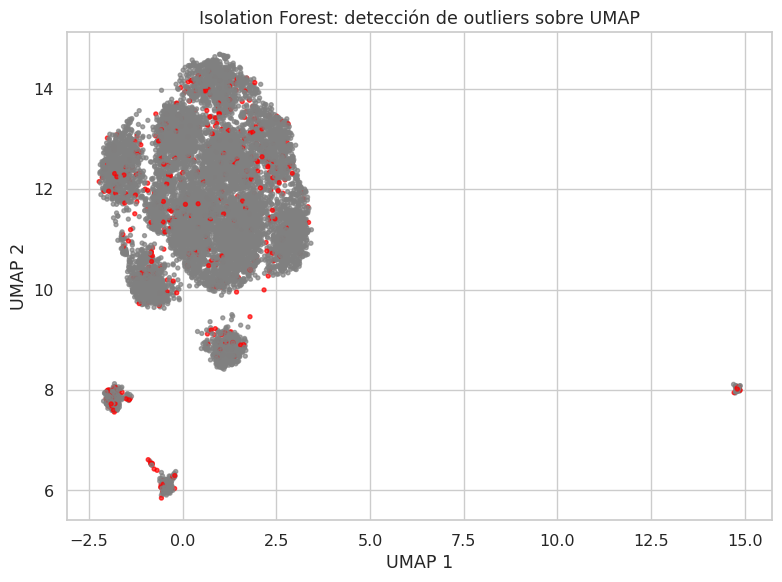

In [21]:
# ============================================================
# 13. ISOLATION FOREST PARA OUTLIERS
# ============================================================

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=SEED,
)

labels_iso = iso.fit_predict(X)  # 1 = normal, -1 = outlier
scores_iso = iso.decision_function(X)

print(f"Outliers detectados: {(labels_iso == -1).sum()} de {len(labels_iso)} ({(labels_iso == -1).mean()*100:.2f}%)")

plt.figure(figsize=(8, 6))
colors = np.where(labels_iso == -1, "red", "gray")
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, s=8, alpha=0.7)
plt.title("Isolation Forest: detección de outliers sobre UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "clustering" / "isolation_forest_umap.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Comparación general de modelos

Se comparan los modelos principales usando métricas internas y externas. K-Means aparece solo como referencia. Los modelos principales considerados para cumplir la guía son HDBSCAN, GMM y Spectral Clustering.

In [22]:
# ============================================================
# 14. TABLA COMPARATIVA DE MÉTRICAS
# ============================================================

summary = pd.DataFrame([
    evaluar_clustering(f"K-Means baseline k={best_kmeans_k}", labels_kmeans, X, y_external, nota="Referencia; no cuenta como algoritmo principal"),
    evaluar_clustering("HDBSCAN optimizado", labels_hdbscan, X, y_external, nota="Algoritmo principal 1"),
    evaluar_clustering(f"GMM optimizado k={best_gmm_k}", labels_gmm, X, y_external, nota="Algoritmo principal 2"),
    evaluar_clustering(
        f"Spectral optimizado k={int(best_spectral_row['k'])}",
        labels_spectral,
        X,
        y_external,
        nota="Algoritmo principal 3",
    ),
])

summary = summary.sort_values("silhouette", ascending=False)
display(summary)

# Guardar métricas para la carpeta results/
summary.to_csv(RESULTS_DIR / "evaluation_metrics.csv", index=False)

# Guardar mejores hiperparámetros
best_params = pd.DataFrame([
    {"modelo": "K-Means", "parametros": json.dumps({"k": best_kmeans_k})},
    {"modelo": "HDBSCAN", "parametros": json.dumps({
        "min_cluster_size": int(best_hdb_row["min_cluster_size"]),
        "min_samples": int(best_hdb_row["min_samples"]),
    })},
    {"modelo": "GMM", "parametros": json.dumps({"k": best_gmm_k, "criterion": "BIC"})},
    {"modelo": "Spectral", "parametros": json.dumps({
        "k": int(best_spectral_row["k"]),
        "n_neighbors": int(best_spectral_row["n_neighbors"]),
    })},
])
best_params.to_csv(RESULTS_DIR / "best_hyperparameters.csv", index=False)

print("Archivos guardados en results/:")
print("- evaluation_metrics.csv")
print("- best_hyperparameters.csv")

,modelo,clusters,ruido_%,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,nota
1,HDBSCAN optimizado,2,0.21,0.1832,1.9522,106.3719,-0.0005,0.0000,Algoritmo principal 1
3,Spectral optimizado k=2,2,0.00,0.1738,1.9602,50.4377,0.0044,0.0003,Algoritmo principal 3
0,K-Means baseline k=3,3,0.00,0.0272,5.7801,175.5313,-0.0067,0.0004,Referencia; no cuenta como algoritmo principal
2,GMM optimizado k=9,9,0.00,0.0214,5.0083,113.1989,-0.0008,0.0004,Algoritmo principal 2


Archivos guardados en results/:
- evaluation_metrics.csv
- best_hyperparameters.csv


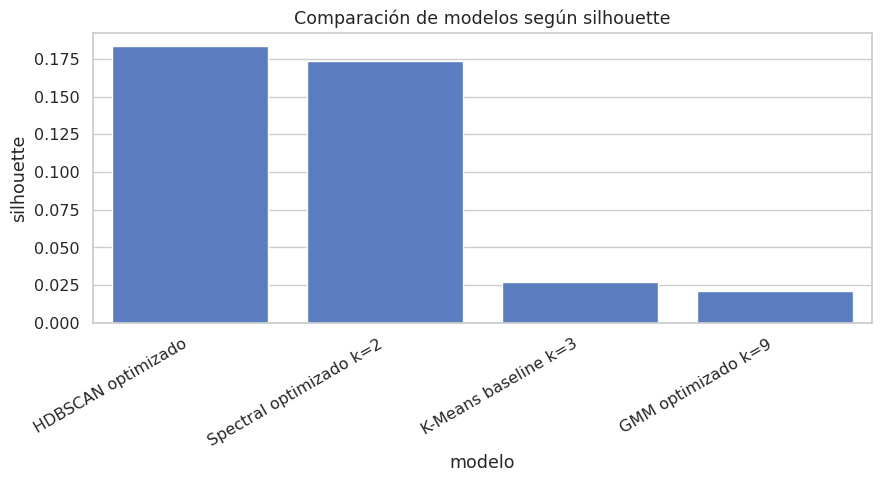

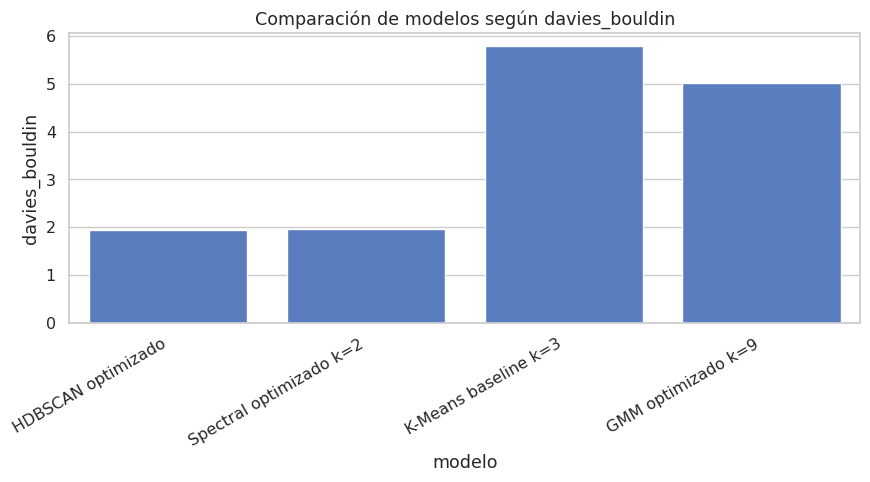

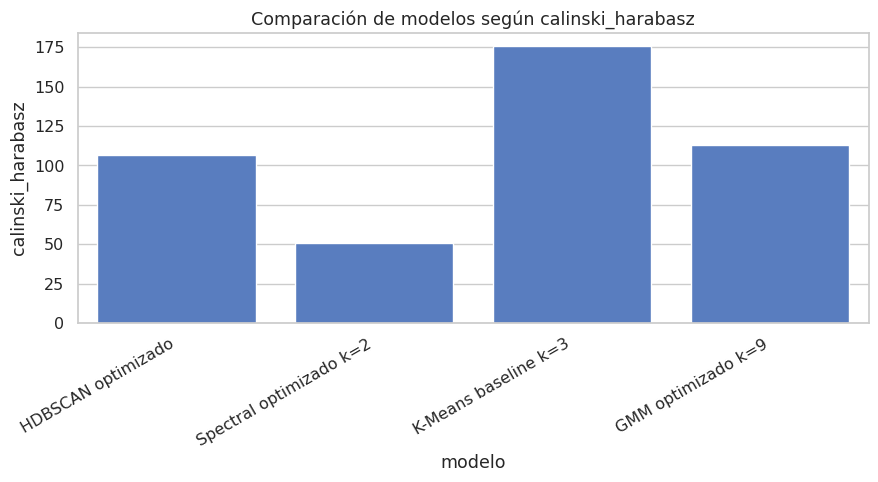

In [23]:
# ============================================================
# 14.1 GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================

metrics_to_plot = ["silhouette", "davies_bouldin", "calinski_harabasz"]

for metric in metrics_to_plot:
    plt.figure(figsize=(9, 5))
    plot_df = summary.dropna(subset=[metric]).copy()
    sns.barplot(data=plot_df, x="modelo", y=metric)
    plt.xticks(rotation=30, ha="right")
    plt.title(f"Comparación de modelos según {metric}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "evaluation" / f"comparacion_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

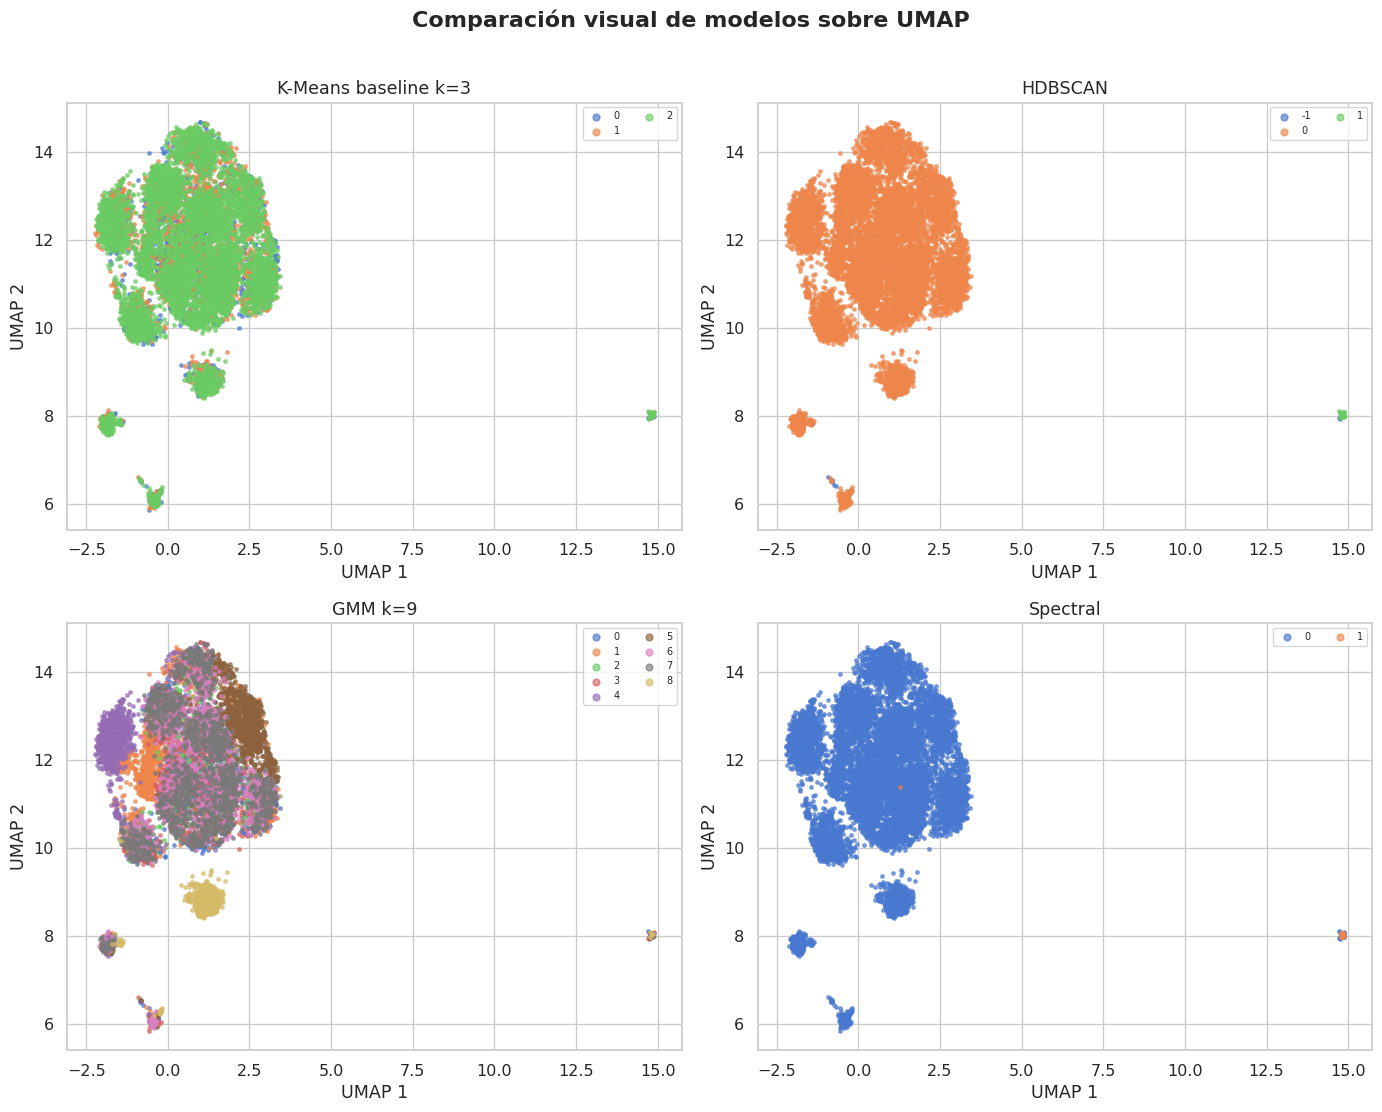

In [24]:
# ============================================================
# 14.2 COMPARACIÓN VISUAL SOBRE UMAP
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
configs = [
    (labels_kmeans, f"K-Means baseline k={best_kmeans_k}", axes[0, 0]),
    (labels_hdbscan, "HDBSCAN", axes[0, 1]),
    (labels_gmm, f"GMM k={best_gmm_k}", axes[1, 0]),
    (labels_spectral, "Spectral", axes[1, 1]),
]

for labels, title, ax in configs:
    labels = np.asarray(labels)
    for lbl in sorted(set(labels)):
        mask = labels == lbl
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1], s=6, alpha=0.65, label=str(lbl))
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(fontsize=7, markerscale=2, ncol=2)

plt.suptitle("Comparación visual de modelos sobre UMAP", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "clustering" / "comparacion_modelos_umap.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Interpretación de clusters

Para interpretar los resultados, se analizan perfiles promedio de variables numéricas por cluster. Esto permite asignar una lectura sustantiva a cada grupo, por ejemplo: perfiles con mayor estrés, menor sueño, mayor apoyo social, mayor satisfacción laboral, etc.

In [25]:
# ============================================================
# 15. PERFILES DE CLUSTERS
# ============================================================

# Variables interpretables: se priorizan las variables numéricas originales.
variables_interpretables = numeric_cols

profiles = {
    "kmeans": perfil_clusters(df, labels_kmeans, variables_interpretables),
    "hdbscan": perfil_clusters(df, labels_hdbscan, variables_interpretables),
    "gmm": perfil_clusters(df, labels_gmm, variables_interpretables),
    "spectral": perfil_clusters(df, labels_spectral, variables_interpretables),
}

for name, profile in profiles.items():
    print(f"\nPerfil promedio por cluster — {name.upper()}")
    display(profile)
    profile.to_csv(RESULTS_DIR / f"cluster_profile_{name}.csv")

# Se guarda una tabla con asignaciones de clusters por observación.
cluster_assignments = pd.DataFrame({
    "kmeans_cluster": labels_kmeans,
    "hdbscan_cluster": labels_hdbscan,
    "gmm_cluster": labels_gmm,
    "spectral_cluster": labels_spectral,
    "isolation_forest_outlier": labels_iso,
})

cluster_assignments.to_csv(RESULTS_DIR / "cluster_assignments.csv", index=False)
print("Asignaciones de clusters guardadas en results/cluster_assignments.csv")


Perfil promedio por cluster — KMEANS


,Age,Work_Hours_Per_Week,Job_Satisfaction,Work_Stress_Level,Work_Life_Balance,Ever_Bullied_At_Work,Sleep_Hours_Night,Caffeine_Drinks_Day,Screen_Time_Hours_Day,Social_Media_Hours_Day,...,Previously_Diagnosed,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Has_Mental_Health_Issue
cluster,,,,,,,,,,,,,,,,,,,,,
0,34.64,39.49,5.47,5.50,5.47,0.25,6.88,1.99,7.03,3.20,...,0.23,0.37,0.19,0.21,0.28,5.36,4.05,5.46,5.50,0.93
1,35.06,39.74,5.46,5.57,5.42,0.24,6.81,2.01,7.10,3.05,...,0.25,0.36,0.19,0.19,0.24,5.44,3.98,5.49,5.46,0.93
2,34.98,39.67,5.53,5.46,5.52,0.25,6.80,2.04,7.06,3.16,...,0.25,0.36,0.19,0.18,0.25,5.49,4.03,5.46,5.43,0.92



Perfil promedio por cluster — HDBSCAN


,Age,Work_Hours_Per_Week,Job_Satisfaction,Work_Stress_Level,Work_Life_Balance,Ever_Bullied_At_Work,Sleep_Hours_Night,Caffeine_Drinks_Day,Screen_Time_Hours_Day,Social_Media_Hours_Day,...,Previously_Diagnosed,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Has_Mental_Health_Issue
cluster,,,,,,,,,,,,,,,,,,,,,
0,34.95,39.65,5.50,5.49,5.49,0.25,6.81,2.02,7.06,3.14,...,0.25,0.36,0.19,0.18,0.25,5.46,4.02,5.47,5.45,0.92
1,34.43,39.96,5.56,5.87,5.69,0.35,6.92,1.88,7.50,3.31,...,0.29,0.36,0.22,0.17,0.24,5.69,3.94,5.90,4.73,0.92



Perfil promedio por cluster — GMM


,Age,Work_Hours_Per_Week,Job_Satisfaction,Work_Stress_Level,Work_Life_Balance,Ever_Bullied_At_Work,Sleep_Hours_Night,Caffeine_Drinks_Day,Screen_Time_Hours_Day,Social_Media_Hours_Day,...,Previously_Diagnosed,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Has_Mental_Health_Issue
cluster,,,,,,,,,,,,,,,,,,,,,
0,34.69,39.61,5.57,5.44,5.56,0.23,6.79,2.07,7.06,3.11,...,0.25,0.36,0.18,0.19,0.25,5.39,3.94,5.51,5.44,0.92
1,34.56,39.60,5.43,5.50,5.30,0.26,6.88,1.98,7.16,3.17,...,0.25,0.36,0.19,0.18,0.24,5.38,4.00,5.54,5.53,0.93
2,34.66,40.04,5.47,5.42,5.54,0.25,6.80,2.01,7.06,3.09,...,0.23,0.38,0.20,0.18,0.23,5.64,4.26,5.48,5.32,0.93
3,34.69,39.19,5.53,5.52,5.49,0.25,6.90,1.96,7.09,3.23,...,0.23,0.36,0.19,0.22,0.29,5.29,4.00,5.48,5.47,0.93
4,34.98,40.19,5.38,5.55,5.64,0.24,6.79,2.04,6.95,3.09,...,0.24,0.37,0.20,0.16,0.26,5.58,4.03,5.44,5.50,0.92
5,34.90,39.59,5.54,5.74,5.60,0.27,6.78,2.07,6.94,3.19,...,0.25,0.38,0.20,0.16,0.26,5.38,3.93,5.47,5.41,0.91
6,35.46,39.66,5.50,5.43,5.38,0.24,6.81,1.99,7.12,3.06,...,0.26,0.34,0.18,0.20,0.23,5.47,3.97,5.42,5.39,0.93
7,35.10,39.62,5.52,5.48,5.48,0.25,6.80,2.00,7.09,3.26,...,0.25,0.37,0.20,0.19,0.25,5.55,4.06,5.43,5.45,0.91
8,35.67,39.53,5.51,5.45,5.40,0.27,6.80,2.09,7.02,2.96,...,0.27,0.35,0.20,0.15,0.26,5.55,4.20,5.46,5.71,0.93



Perfil promedio por cluster — SPECTRAL


,Age,Work_Hours_Per_Week,Job_Satisfaction,Work_Stress_Level,Work_Life_Balance,Ever_Bullied_At_Work,Sleep_Hours_Night,Caffeine_Drinks_Day,Screen_Time_Hours_Day,Social_Media_Hours_Day,...,Previously_Diagnosed,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Has_Mental_Health_Issue
cluster,,,,,,,,,,,,,,,,,,,,,
0,34.95,39.66,5.51,5.49,5.49,0.25,6.81,2.03,7.06,3.14,...,0.25,0.36,0.19,0.18,0.25,5.46,4.02,5.47,5.45,0.92
1,34.29,40.18,4.92,5.67,5.96,0.35,7.05,1.53,7.56,3.50,...,0.31,0.31,0.22,0.12,0.29,5.35,3.57,5.92,4.69,0.88


Asignaciones de clusters guardadas en results/cluster_assignments.csv


## 18. Referencias

- McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction*.
- Campello, R. J. G. B., Moulavi, D., & Sander, J. (2013). *Density-Based Clustering Based on Hierarchical Density Estimates*.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*.
- Kaggle Dataset: `dhrubangtalukdar/global-mental-health-and-lifestyle-survey-dataset`.

---

## Archivos generados por este notebook

Al ejecutar todas las celdas, se generan archivos en:

```text
figures/eda/
figures/clustering/
figures/evaluation/
results/
```